# KNN Exercise

![iris](assets/iris.jpg)

We are going to use the famous **iris data set** again. 

The dataset consists of four attributes, which can be used to distinguish different iris species: 
* sepal-width
* sepal-length
* petal-width 
* petal-length. 


The task is to predict the class to which these plants belong. There are three classes in the dataset: **Iris-setosa, Iris-versicolor and Iris-virginica.** 

Further details of the dataset are available [here](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html).

## Task

1. Please import and pre-process the data (as far as it's necessary). Afterwards split it in a train and test set, fit a KNN model and make predictions on the test set. The last step is to evaluate your model. Try to also scale your data and fit the model to the unscaled and scaled data. Can you see a difference in performance? 
If you can't it's because the original features are all on a very similar scale. Try multiplying one of the features by a factor of 10 and fitting the model to unscaled and scaled data. The difference should now be obvious 

2. Please also calculate the accuracy for K values of 1 to 40. In each iteration the accuracy for the predicted values of the test set is calculated and the result is appended to an error list.
The next step is to plot the accuracy values against K values.

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target classes:
['setosa' 'versicolor' 'virginica']

Shape of X: (150, 4)
Shape of y: (150,)
Accuracy without scaling: 1.0
Accuracy with scaling: 0.9333333333333333

Accuracy after multiplying one feature by 10 (without scaling): 0.7333333333333333
Accuracy after multiplying one feature by 10 (with scaling): 0.9333333333333333


,Experiment,Accuracy
0,Original - No Scaling,1.000000
1,Original - Scaling,0.933333
2,Modified x10 - No Scaling,0.733333
3,Modified x10 - Scaling,0.933333


,K,Accuracy
0,1,0.966667
1,2,0.933333
2,3,0.933333
3,4,0.933333
4,5,0.933333
5,6,0.933333
6,7,0.966667
7,8,0.933333
8,9,0.966667
9,10,0.966667


Best K: 1
Best Accuracy: 0.9666666666666667


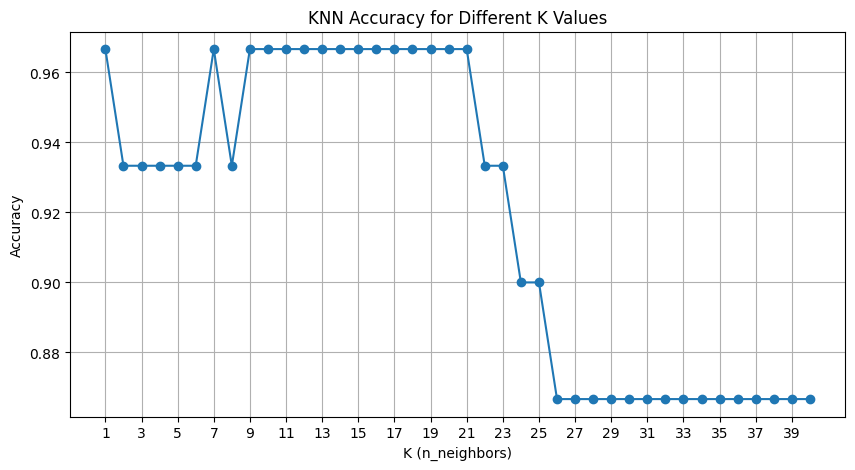

In [1]:
# ============================================
# KNN Exercise - Iris Dataset
# ============================================

# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


# ============================================
# 2. Load the Iris dataset
# ============================================

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target

print("Features:")
display(X.head())

print("\nTarget classes:")
print(iris.target_names)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


# ============================================
# 3. Split into training and test sets
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================
# 4. KNN WITHOUT scaling
# ============================================

knn_unscaled = KNeighborsClassifier(n_neighbors=5)

knn_unscaled.fit(X_train, y_train)

y_pred_unscaled = knn_unscaled.predict(X_test)

accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)

print("Accuracy without scaling:", accuracy_unscaled)


# ============================================
# 5. KNN WITH scaling
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)

knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Accuracy with scaling:", accuracy_scaled)


# ============================================
# 6. Multiply one feature by 10
# ============================================

X_modified = X.copy()

# Multiply sepal length by 10
X_modified["sepal length (cm)"] = (
    X_modified["sepal length (cm)"] * 10
)

X_train_mod, X_test_mod, y_train_mod, y_test_mod = train_test_split(
    X_modified,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================
# 7. KNN on modified data WITHOUT scaling
# ============================================

knn_modified_unscaled = KNeighborsClassifier(n_neighbors=5)

knn_modified_unscaled.fit(X_train_mod, y_train_mod)

y_pred_modified_unscaled = knn_modified_unscaled.predict(X_test_mod)

accuracy_modified_unscaled = accuracy_score(
    y_test_mod,
    y_pred_modified_unscaled
)

print(
    "\nAccuracy after multiplying one feature by 10 "
    "(without scaling):",
    accuracy_modified_unscaled
)


# ============================================
# 8. KNN on modified data WITH scaling
# ============================================

scaler_modified = StandardScaler()

X_train_mod_scaled = scaler_modified.fit_transform(X_train_mod)
X_test_mod_scaled = scaler_modified.transform(X_test_mod)

knn_modified_scaled = KNeighborsClassifier(n_neighbors=5)

knn_modified_scaled.fit(
    X_train_mod_scaled,
    y_train_mod
)

y_pred_modified_scaled = knn_modified_scaled.predict(
    X_test_mod_scaled
)

accuracy_modified_scaled = accuracy_score(
    y_test_mod,
    y_pred_modified_scaled
)

print(
    "Accuracy after multiplying one feature by 10 "
    "(with scaling):",
    accuracy_modified_scaled
)


# ============================================
# 9. Compare the four results
# ============================================

results = pd.DataFrame({
    "Experiment": [
        "Original - No Scaling",
        "Original - Scaling",
        "Modified x10 - No Scaling",
        "Modified x10 - Scaling"
    ],
    "Accuracy": [
        accuracy_unscaled,
        accuracy_scaled,
        accuracy_modified_unscaled,
        accuracy_modified_scaled
    ]
})

display(results)


# ============================================
# 10. Accuracy for K = 1 to 40
# ============================================

k_values = range(1, 41)

accuracy_values = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    predictions = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    accuracy_values.append(accuracy)


# ============================================
# 11. Display K and Accuracy
# ============================================

k_results = pd.DataFrame({
    "K": list(k_values),
    "Accuracy": accuracy_values
})

display(k_results)


# ============================================
# 12. Find the highest accuracy
# ============================================

best_index = np.argmax(accuracy_values)

best_k = list(k_values)[best_index]
best_accuracy = accuracy_values[best_index]

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)


# ============================================
# 13. Plot Accuracy against K
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    list(k_values),
    accuracy_values,
    marker="o"
)

plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.xticks(range(1, 41, 2))
plt.grid(True)

plt.show()